In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import sys
import re
import ast
from scipy.integrate import solve_ivp
from pathlib import Path

In [ ]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from configuration.settings import *
from model.dynamic import PEMFC_dyn
from model.static import PEMFC_stat
from model.coefficients import *
from configuration.initialize import *
from data.load_experiment import load_aux_data_exp

hfr_path = project_root / "data" / "HFR.xlsx"
xls = pd.ExcelFile(hfr_path)

# Simulation Report

This manuscript presents a comparative analysis of static and dynamic PEMFC simulations for massflow and transport-related states under a stepped current profile.

The objective is to evaluate model fidelity against experimental trends and to clarify where dynamic state accumulation improves prediction compared with quasi-steady algebraic closures.

In [3]:
I_points = [10, 20, 30, 35, 40, 45, 50]

dyn_log_all = {}

for RHC in [0, 0.5]:
    for P_des in [1.3,1.4,1.5]:
        for T_des in [50,60,70]:
            if RHC == 0 and P_des != 1.3:
                continue # Skip the condition that not yet carried out on the experimental side
            else:
                pass

            states_dyn_log = []
            time_evolutions = []
            massflow_dyn_log = []

            for I_LOAD in I_points:
                # --------------- Dynamic Simulation  --------------- #
                operating_inputs["Phi_c_des"] = RHC 
                operating_inputs["Pa_des"] = P_des * 1e5
                operating_inputs["Pc_des"] = P_des * 1e5
                operating_inputs["Tfc"] = T_des + 273.15
                operating_inputs["current_density"] = lambda x: I_LOAD/parameters["Aact"]
                x_init = init_x(operating_inputs, parameters)
                model = PEMFC_dyn(parameters,operating_inputs, x_init)
                sol = solve_ivp(model.dxdt, (0, 60), x_init, method='BDF', max_step=1e-1)
                model._recovery(sol)
                # --------------- Log states for dynamic simulation  --------------- #
                states = {} # Log the last state values for each variable => pseudo steady-state values 
                time_evo = {} # Log the time evolution of each variable => check for convergence to steady-state
                for key, var_name in enumerate(model.variables):
                    states[var_name] = model.variables[var_name][-1]
                    time_evo[var_name] = model.variables[var_name]
                for key, var_name in enumerate(model.elec_variables):
                    states[var_name] = model.elec_variables[var_name][-1]
                    time_evo[var_name] = model.elec_variables[var_name]
                massflow_dyn = model.calculate_flows(sol.t[-1], states)

                states_dyn_log.append(states)
                time_evolutions.append(time_evo)
                massflow_dyn_log.append(massflow_dyn)
                
            # --------------- Log states profile for both simulations  --------------- #
            states_profile_dyn = {}
            for key, value in enumerate(states_dyn_log[0].keys()):
                states_profile_dyn[value] = [states[value] for states in states_dyn_log]
            dyn_log_all["RHA"+str(0)+"/RHC" + str(RHC) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_profile_dyn, "time_evolution":time_evolutions, "massflow": massflow_dyn_log}

## Steady-State Verification of the Dynamic Model

Before model-to-model and model-to-experiment comparison, the dynamic simulation is checked for convergence to a pseudo-steady state.

For each operating point, the state vector is advanced in time until the trajectories become approximately flat (practically around 40-60 s in this notebook), which is used as the extraction point for comparison with static results.

Conceptually, this corresponds to the steady condition $\frac{d\mathbf{x}}{dt}\approx 0$.

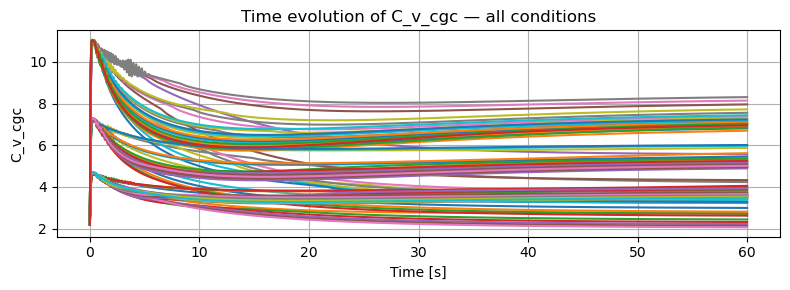

In [4]:
fig, ax = plt.subplots(figsize=(8, 3))

for cond_key, cond_data in dyn_log_all.items():
    for j, I in enumerate(I_points):
        te = cond_data["time_evolution"][j]
        ax.plot(te["t"], te["C_v_cgc"], label=f"{cond_key}, I={I}A")

ax.set_xlabel("Time [s]")
ax.set_ylabel("C_v_cgc")
ax.set_title("Time evolution of C_v_cgc — all conditions")
ax.grid(True)
fig.tight_layout()
plt.show()

The convergence plot indicates that cathode gas-channel vapor concentration reaches a near-steady plateau after approximately 40 s for the tested operating points, supporting the use of end-of-window dynamic states for static-versus-dynamic comparison.

In [5]:
stat_log_all = {}

for RHC in [0, 0.5]:
    for P_des in [1.3,1.4,1.5]:
        for T_des in [50,60,70]:
            if RHC == 0 and P_des != 1.3:
                continue # Skip the condition that not yet carried out on the experimental side
            else:
                pass
            states_stat = []
            for I_LOAD in I_points:
                # --------------- Steady-state Simulation  --------------- #
                Wout_c = 10 + I_LOAD * 2.
                Win_c = 1 + I_LOAD *2.5
                Wout_a = 10 + I_LOAD * 3
                operating_inputs_stat = {'Tfc': T_des + 273.15, 'Phi_a_des': 0, 'Phi_c_des': RHC,
                                                             'Pa_des': P_des * 1e5, 'Pc_des': P_des * 1e5,
                                                             'Win_c': Win_c, 'Wout_c': Wout_c, 'Win_a': 0, 'Wout_a': Wout_a}
                model = PEMFC_stat(parameters,operating_inputs_stat)
                sol = model.solve(I_LOAD/parameters['Aact'])
                # --------------- Log states for steady-state simulation  --------------- #
                states_stat.append(sol)
            # --------------- Log states for both simulations  --------------- #
            stat_log_all["RHA"+str(0)+"/RHC" + str(RHC) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_stat}

In [6]:
aux_data_exp = load_aux_data_exp(project_root, stat_log_all, dyn_log_all, I_points)
loaded = sum(bool(v.get("states")) for v in aux_data_exp.values())

## Gas Supply System Modeling Validation

### 1. Experimental Data

Gas supply variables are first inspected from measurements to establish reference trends versus load current. The inlet-side flow and humidity measurements provide boundary-condition targets for the simulation workflow.

### 2. Modeling Rationale

In the dynamic formulation, manifold pressure regulation introduces transient coupling between commanded operating conditions and effective channel inflow/outflow. In the static formulation, boundary conditions are imposed algebraically from operating inputs, without temporal manifold dynamics.

Therefore, agreement/disagreement between the two formulations is interpreted in terms of dynamic actuator/manifold effects versus quasi-steady closure assumptions.

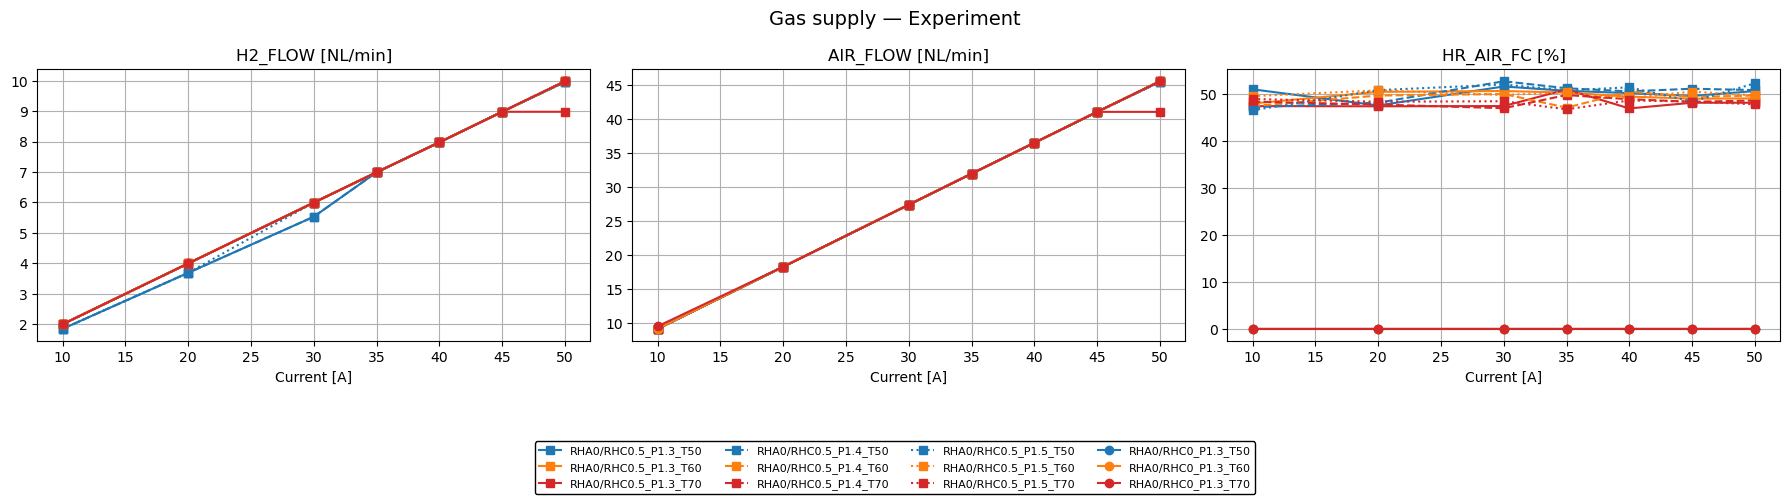

In [7]:
cols_to_plot = [("H2_FLOW", "H2_FLOW [NL/min]"), ("AIR_FLOW", "AIR_FLOW [NL/min]"),  ("HR_AIR_FC", "HR_AIR_FC [%]")]
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
fig.suptitle("Gas supply — Experiment", fontsize=14)
handles, labels = [], [] 
for key in aux_data_exp.keys():
    props = get_plot_properties(key)
    exp_states = aux_data_exp[key].get("states", {})
    line = None
    for ax, (col, col_label) in zip(axes.flatten(), cols_to_plot):
        if col in exp_states:
            l, = ax.plot(I_points, exp_states[col], color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
            if line is None:
                line = l
    if line is None:  # condition had no data — add dummy handle for legend completeness
        line, = axes[0].plot([], [], color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    handles.append(line)
    labels.append(key)
for ax, (col, col_label) in zip(axes.flatten(), cols_to_plot):
    ax.set_title(col_label)
    ax.set_xlabel("Current [A]")
    ax.grid(True)
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0),
                 ncol=4, fontsize=8, frameon=True, facecolor='white',
                 edgecolor='black', framealpha=1.0)
plt.tight_layout(rect=[0, 0.2, 1, 1])
plt.show()

### Validation of Simulated Supply-Side States

The following figure compares dynamic-model actuator-side flow predictions against measured supply trends, using a common condition styling map (temperature-color, pressure-linestyle, humidity-marker) for traceability across all sections.

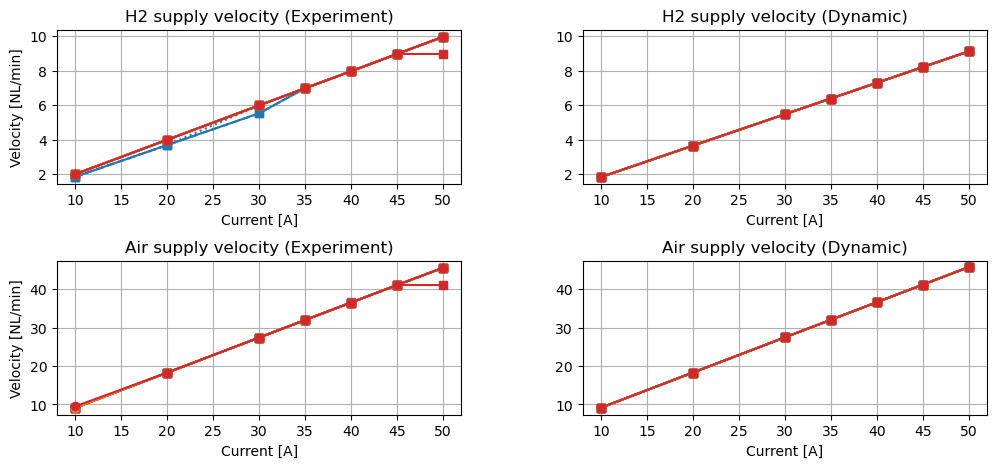

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for key in aux_data_exp.keys():
    props = get_plot_properties(key)
    exp_states = aux_data_exp[key].get("states", {})
    axes[0, 0].plot(I_points,  exp_states["H2_FLOW"], color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[1, 0].plot(I_points, exp_states["AIR_FLOW"], color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
for cond_key, cond_data in dyn_log_all.items():
    props = get_plot_properties(cond_key)
    states = cond_data["states"]
    Wcp_NLmin = np.array(states["Wcp"])/2.155e-5 # V_NLMIN * M_O2/(Vm_std*60)
    Wrd_NLmin = np.array(states["Wasm_in"])/1.499e-6 # V_NLMIN * M_H2/(Vm_std*60)
    axes[1, 1].plot(I_points, Wcp_NLmin, color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[0, 1].plot(I_points, Wrd_NLmin, color=props['color'], linestyle=props['linestyle'], marker=props['marker'])

axes[0, 1].set_ylim(axes[0, 0].get_ylim()); axes[0,1].grid(True)
axes[1, 1].set_ylim(axes[1, 0].get_ylim()); axes[1,1].grid(True)
axes[0, 0].set_ylabel("Velocity [NL/min]")
axes[1, 0].set_ylabel("Velocity [NL/min]")
axes[0, 0].set_title("H2 supply velocity (Experiment)"); axes[0, 0].set_xlabel("Current [A]"); axes[0, 0].grid(True)
axes[0, 1].set_title("H2 supply velocity (Dynamic)"); axes[0, 1].set_xlabel("Current [A]"); axes[0, 1].grid(True)
axes[1, 0].set_title("Air supply velocity (Experiment)"); axes[1, 0].set_xlabel("Current [A]"); axes[1, 0].grid(True)
axes[1, 1].set_title("Air supply velocity (Dynamic)"); axes[1, 1].set_xlabel("Current [A]"); axes[1, 1].grid(True)

## Gas Channel Massflow Comparison

This section compares static and dynamic formulations for gas-channel vapor transport and discusses the physical implications for model interpretation.

### Static Formulation (Algebraic Closure)

Under quasi-steady assumptions, channel states are obtained from algebraic mass-balance relations. For the cathode gas channel vapor concentration:

$$C_{v,cgc}=\frac{J_w\,L_{gc}/H_{gc}+C_{v,in}\,W_{in}}{W_{out}}$$

where $J_w$ is the net water source term toward the channel, $C_{v,in}$ is inlet vapor concentration, and $W_{in},W_{out}$ are inlet/outlet flow rates.

### Dynamic Formulation (Transient Conservation)

The dynamic model resolves temporal accumulation:

$$\frac{dC_{v,cgc}}{dt}=\frac{J_{v,c,in}-J_{v,c,out}}{L_{gc}}+\frac{J_{v,cgdl\rightarrow cgc}}{H_{gc}}$$

This allows transient deviation from steady closure during load or boundary-condition changes.

### Interpretation Framework

- Static results represent equilibrium endpoints for each operating point.
- Dynamic results contain both transient trajectories and final pseudo-steady values.
- Discrepancies between both models are expected when manifold dynamics and inter-domain transport time constants are significant.

The following cathode and anode subsections report these comparisons using identical condition encoding to ensure visual consistency and reproducibility.

### Cathode gas channel 

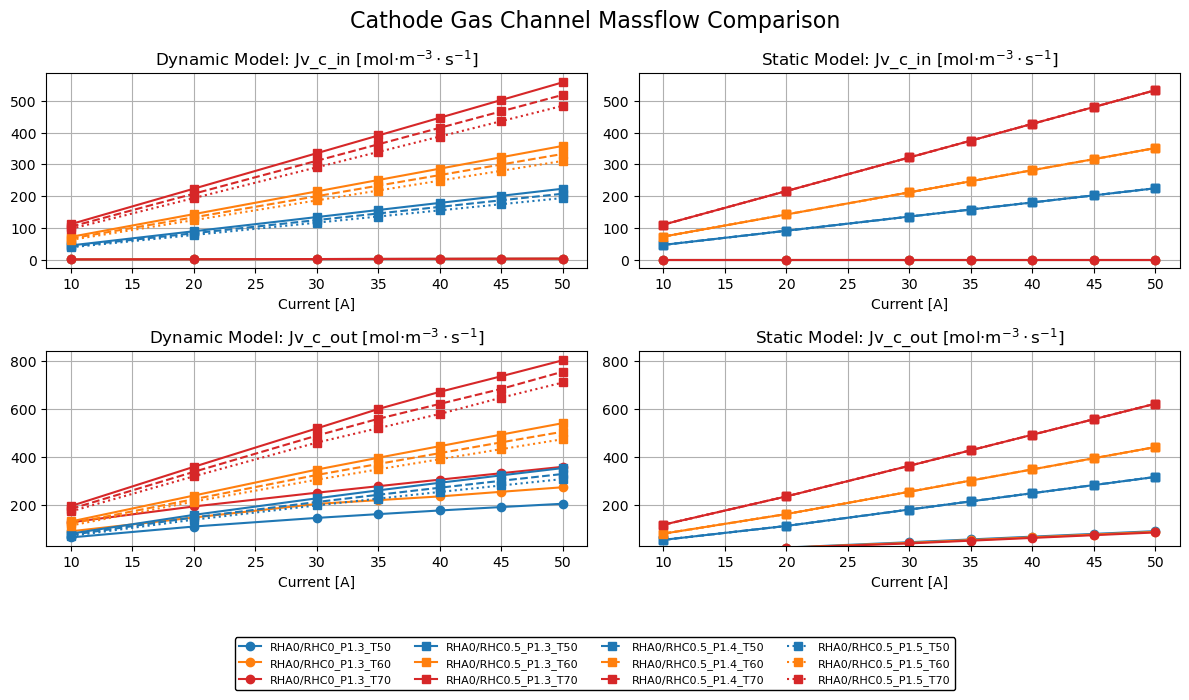

In [9]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))
fig.suptitle("Cathode Gas Channel Massflow Comparison", fontsize=16)
Vm_STP = R * 273.15 / 101325
V_gc_total = n_cell * parameters["Hgc"] * parameters["Wgc"] * parameters["Lgc"]


handles, labels = [], []
for key in dyn_log_all.keys():
    props = get_plot_properties(key)
    states_stat = stat_log_all[key]["states"]
    massflow_dyn = dyn_log_all[key]["massflow"]

    line, = axes[0,0].plot(I_points, [massflow["Jv_c_in"] for massflow in massflow_dyn],
                                       color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[0,1].plot(I_points, [states["Jv_c_in"] for states in states_stat],
                   color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[1,0].plot(I_points, [massflow["Jv_c_out"] for massflow in massflow_dyn],
                           color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[1,1].plot(I_points, [states["Jv_c_out"] for states in states_stat],
                           color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    handles.append(line)
    labels.append(key)

axes[0,0].set_title(r"Dynamic Model: Jv_c_in [mol$\cdot$m$^{-3}\cdot$s$^{-1}$]"); axes[0,0].set_xlabel("Current [A]"); axes[0,0].grid(True)
axes[0,1].set_title(r"Static Model: Jv_c_in [mol$\cdot$m$^{-3}\cdot$s$^{-1}$]"); axes[0,1].set_xlabel("Current [A]"); axes[0,1].grid(True)
axes[0,1].set_ylim(axes[0,0].get_ylim())
axes[1,1].set_ylim(axes[1,0].get_ylim())
axes[1,0].set_title(r"Dynamic Model: Jv_c_out [mol$\cdot$m$^{-3}\cdot$s$^{-1}$]"); axes[1,0].set_xlabel("Current [A]"); axes[1,0].grid(True)
axes[1,1].set_title(r"Static Model: Jv_c_out [mol$\cdot$m$^{-3}\cdot$s$^{-1}$]"); axes[1,1].set_xlabel("Current [A]"); axes[1,1].grid(True)

fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0),
                  ncol=4, fontsize=8, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0)
plt.tight_layout(rect=[0, 0.13, 1, 1])
plt.show()

The observed inlet-flow differences between static and dynamic predictions are consistent with the modeling assumptions: manifold/actuator transients are represented in the dynamic model, whereas static calculations enforce instantaneous algebraic boundary closure.

### Anode gas channel

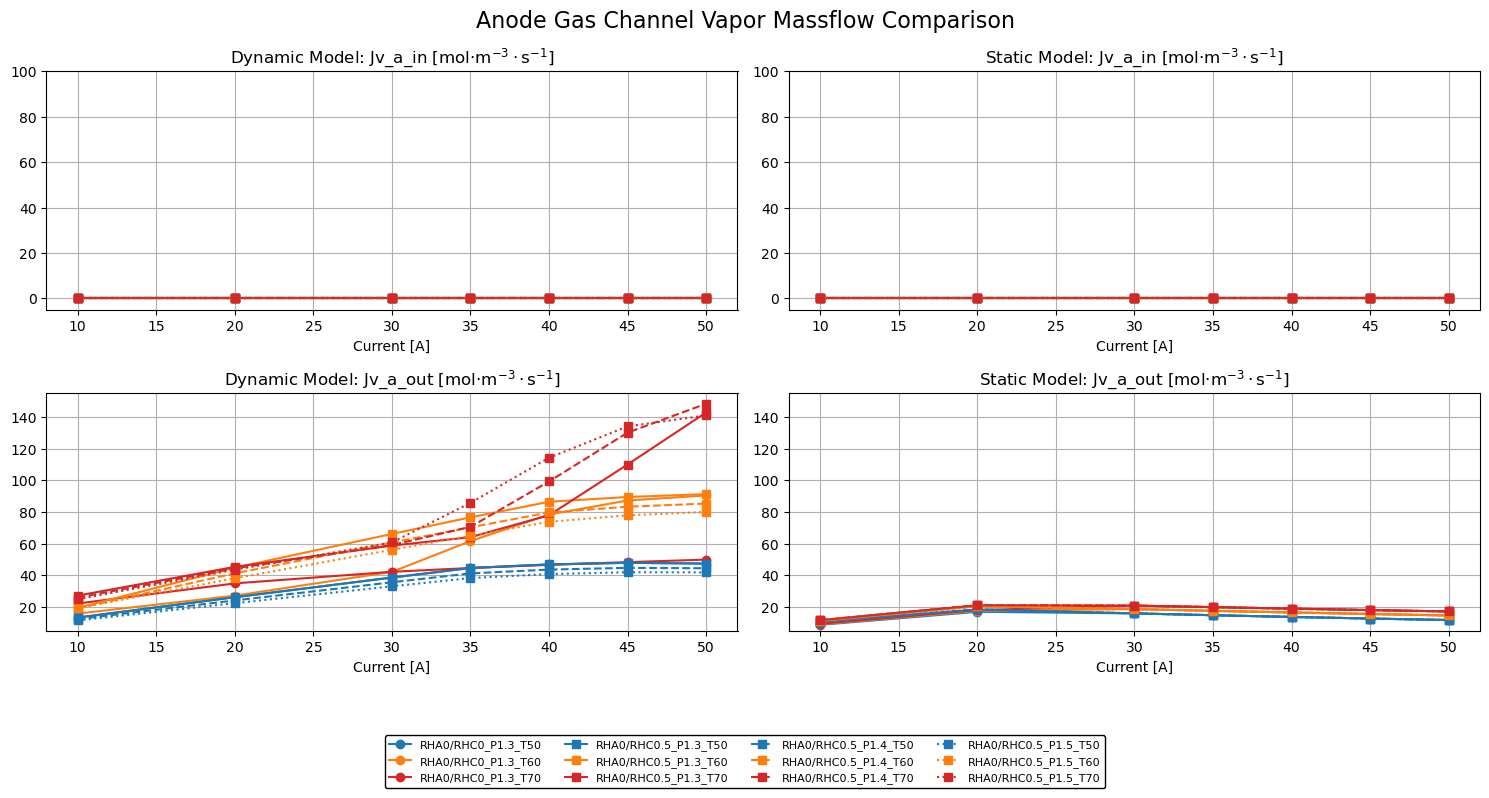

In [31]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))
fig.suptitle("Anode Gas Channel Vapor Massflow Comparison", fontsize=16)

handles, labels = [], []
for key in dyn_log_all.keys():
    props = get_plot_properties(key)
    states_stat = stat_log_all[key]["states"]
    massflow_dyn = dyn_log_all[key]["massflow"]

    line, = axes[0,0].plot(I_points, [massflow["Jv_a_in"] for massflow in massflow_dyn], color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[0,1].plot(I_points, [states["Jv_a_in"] for states in states_stat], color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[1,0].plot(I_points, [massflow["Jv_a_out"] for massflow in massflow_dyn], color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[1,1].plot(I_points, [states["Jv_a_out"] for states in states_stat], color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    handles.append(line)
    labels.append(key)

axes[0,0].set_title(r"Dynamic Model: Jv_a_in [mol$\cdot$m$^{-3}\cdot$s$^{-1}$]"); axes[0,0].set_xlabel("Current [A]"); axes[0,0].grid(True)
axes[0,1].set_title(r"Static Model: Jv_a_in [mol$\cdot$m$^{-3}\cdot$s$^{-1}$]"); axes[0,1].set_xlabel("Current [A]"); axes[0,1].grid(True)
axes[1,0].set_title(r"Dynamic Model: Jv_a_out [mol$\cdot$m$^{-3}\cdot$s$^{-1}$]"); axes[1,0].set_xlabel("Current [A]"); axes[1,0].grid(True)
axes[1,1].set_title(r"Static Model: Jv_a_out [mol$\cdot$m$^{-3}\cdot$s$^{-1}$]"); axes[1,1].set_xlabel("Current [A]"); axes[1,1].grid(True)
axes[0,0].set_ylim(-5,100)
axes[0,1].set_ylim(axes[0,0].get_ylim())
axes[1,1].set_ylim(axes[1,0].get_ylim())

fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0), ncol=4, fontsize=8, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0)
plt.tight_layout(rect=[0, 0.13, 1, 1])
plt.show()

## GDL Massflow Comparison (Anode vs Cathode)

The equations below are the GDL state equations used in this project (from `model/dynamic.py`, `model/static.py`, and summarized in `README.md`).

#### Dynamic model (state equations)
For each GDL node $i$:

$$\frac{dC_{v,gdl,i}}{dt}=\frac{1}{\varepsilon_{gdl}(1-s_i)}\left(\frac{J_{v,i-1}-J_{v,i}}{\Delta x_{gdl}}+S_{v,i}\right)$$

$$\frac{dC_{v,gdl,i}}{dt}=\frac{1}{\varepsilon_{gdl}(1-s_i)}\left(\frac{J_{v,i-1}-J_{v,i}}{\Delta x_{gdl}}\right)$$

$$\frac{ds_{gdl,i}}{dt}=\frac{1}{\rho_{H_2O}\,\varepsilon_{gdl}}\left(\frac{J_{l,i-1}-J_{l,i}}{\Delta x_{gdl}}+M_{H_2O}S_{l,i}\right)$$

In code, the plotted dynamic GDL liquid fluxes are:
- Anode side: `Jl_agdl_acl`
- Cathode side: `Jl_ccl_cgdl`

#### Static model (algebraic equations)
No time derivative is solved in the static model. The GDL is computed from algebraic profiles:

$$C_{v,gdl}(x)=C_{v,inter}+\frac{x}{D_{eff}}J_w$$


Saturation is obtained from Leverett-type inversion in `gdl_profile(...)` (via `self._solve_sat(...)`), with front tracking by:

$$x_{front}=\frac{(C_{v,sat}-C_{v,inter})D_{eff}}{J_w}$$

In the static results used in the plot:
- Anode-side water flux proxy: `Jw_an`
- Cathode-side water flux proxy: `Jw_ca`

So this figure compares dynamic GDL transport fluxes against their static algebraic counterparts for both anode and cathode.

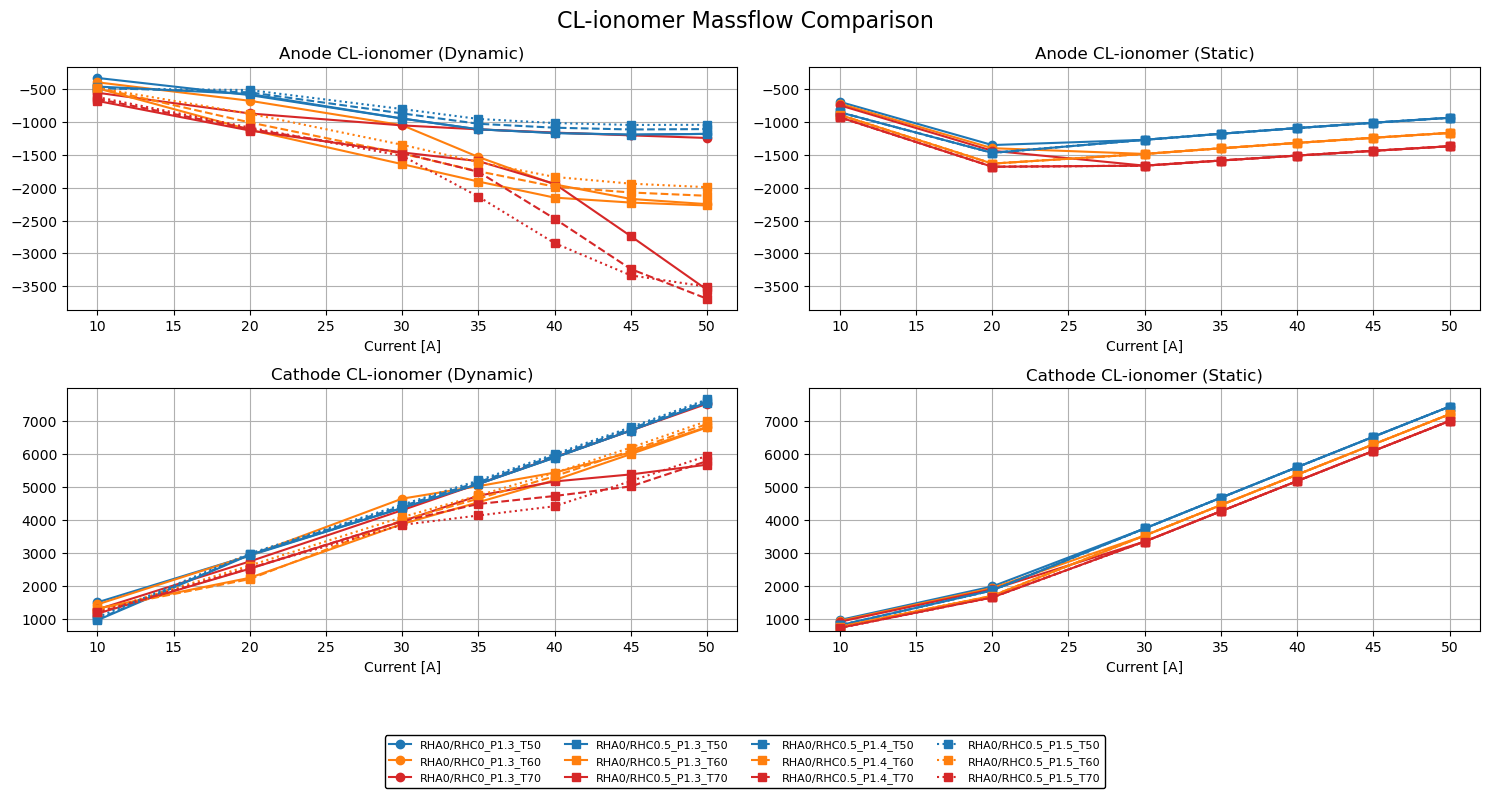

In [33]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))
fig.suptitle("CL-ionomer Massflow Comparison", fontsize=16)

handles, labels = [], []
for key in dyn_log_all.keys():
    props = get_plot_properties(key)
    states_stat = stat_log_all[key]["states"]
    massflow_dyn = dyn_log_all[key]["massflow"]

    line, = axes[0,0].plot(I_points, [massflow["S_sorp_acl"] for massflow in massflow_dyn],
                           color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[0,1].plot(I_points, [-states["Jw_an"]/parameters["Hcl"] for states in states_stat],
                   color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[1,0].plot(I_points, [-massflow["S_sorp_ccl"] for massflow in massflow_dyn],
                   color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[1,1].plot(I_points, [states["Jw_ca"]/parameters["Hcl"] for states in states_stat],
                   color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    handles.append(line)
    labels.append(key)

axes[0,0].set_title("Anode CL-ionomer (Dynamic)"); axes[0,0].set_xlabel("Current [A]"); 
axes[0,0].grid(True)
axes[0,1].set_title("Anode CL-ionomer (Static)"); axes[0,1].set_xlabel("Current [A]")
axes[0,1].set_ylim(axes[0,0].get_ylim())
axes[0,1].grid(True)
axes[1,0].set_title("Cathode CL-ionomer (Dynamic)"); axes[1,0].set_xlabel("Current [A]"); axes[1,0].grid(True)
axes[1,1].set_title("Cathode CL-ionomer (Static)"); axes[1,1].set_xlabel("Current [A]")
axes[1,1].set_ylim(axes[1,0].get_ylim())
axes[1,1].grid(True)

fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0),
                  ncol=4, fontsize=8, frameon=True, facecolor='white',
                  edgecolor='black', framealpha=1.0)
plt.tight_layout(rect=[0, 0.13, 1, 1])
plt.show()

### Derivation for the CL-Ionomer Comparison (Figure Above)

The previous figure compares:

- Dynamic terms: $S_{sorp,acl}$ and $-S_{sorp,ccl}$
- Static proxies: $-J_{w,an}/H_{cl}$ and $J_{w,ca}/H_{cl}$

This is a consistency comparison, not strict equality of identical variables.

#### 1. Static model

The static model solution establishes the mass conservation by assuming that the amount of the water generation equals to the sum of membrane water flow at anode side and cathode side:

$J_{w,ca}=\frac{i}{2F}-J_{net},\qquad J_{w,an}=J_{net}$

#### 2. Dynamic model

$$S_{sorp,acl}=\gamma_{sorp}(\cdot)\frac{\rho_{mem}}{M_{eq}}\left(\lambda_{eq,acl}-\lambda_{acl}\right),\qquad S_{sorp,ccl}=\gamma_{sorp}(\cdot)\frac{\rho_{mem}}{M_{eq}}\left(\lambda_{eq,ccl}-\lambda_{ccl}\right).$$

ACL and CCL water-content balances are:

$\frac{d\lambda_{acl}}{dt}=\frac{M_{eq}}{\rho_{mem}\epsilon_{mc}}\left(-\frac{J_{\lambda,acl\rightarrow mem}}{\delta_{acl}}+S_{sorp,acl}\right),\quad \delta_{acl}=H_{mem}/n_{mem}$

$\frac{d\lambda_{ccl}}{dt}=\frac{M_{eq}}{\rho_{mem}\epsilon_{mc}}\left(\frac{J_{\lambda,ccl\rightarrow mem}}{\delta_{ccl}}+S_{sorp,ccl}+S_{p,ccl}\right),\quad \delta_{ccl}=H_{mem}/n_{mem}$

with

$S_{p,ccl}=\frac{i}{2FH_{cl}}.$


## Membrane Dissolved-Water Flux Comparison for the Next Figure

The next figure compares dynamic membrane dissolved-water fluxes with the static membrane flux closure.

### Dynamic quantities (left panels)

- Mean internal membrane flux: $\overline{J_{\lambda,mem}}$
- ACL interface flux: $J_{\lambda,acl\rightarrow mem}$
- CCL interface flux: $J_{\lambda,ccl\rightarrow mem}$

The dynamic local law is:

$$J_{\lambda}=\frac{2.5}{22}\frac{i}{F}\lambda-\frac{\rho_{mem}}{M_{eq}}D(\lambda,T)\frac{\partial\lambda}{\partial x}.$$

### Static quantity (right panels)

The static model provides a single effective through-membrane flux $J_{mem}$:

$$J_{mem}=-\frac{2.5}{22}\frac{i}{F}\frac{\lambda_{ccl}e^{-H_{mem}/K_{\lambda}}-\lambda_{acl}}{e^{-H_{mem}/K_{\lambda}}-1}.$$

In the code, this static reference is plotted as $-J_{mem}$ in all three right panels.

### Interpretation

- Dynamic model resolves spatial/interface differences across the membrane.
- Static model collapses transport into one global steady flux.
- Therefore, exact overlap is not required; agreement is evaluated at trend level and magnitude order under each operating condition.

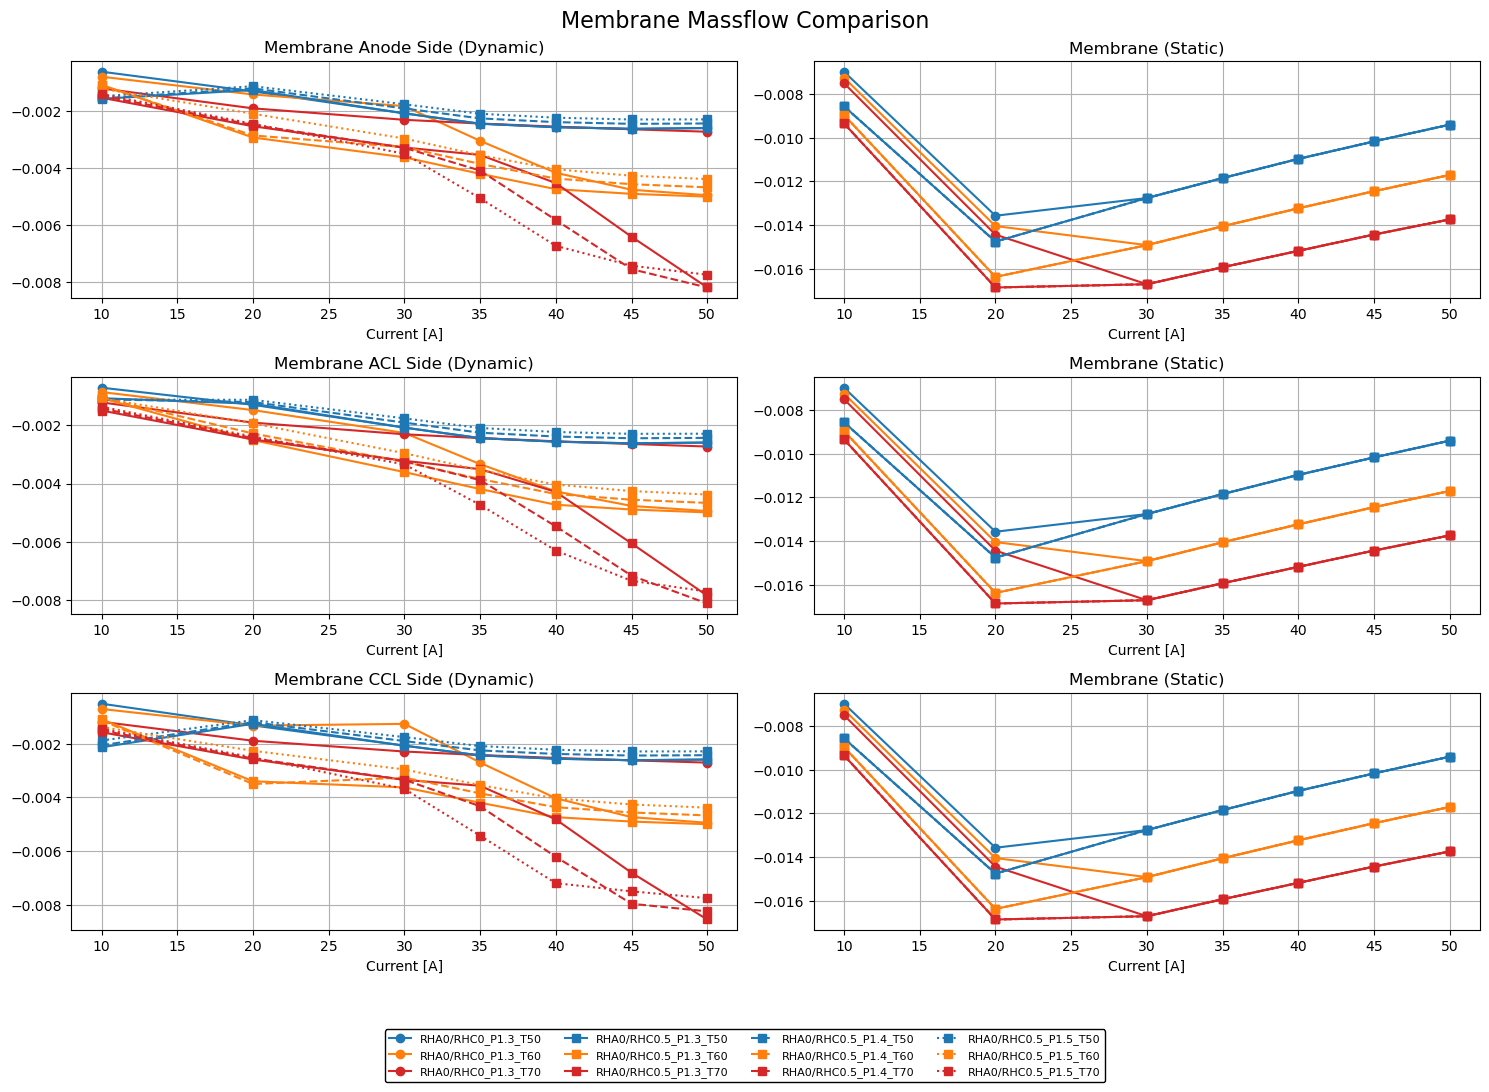

In [13]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 11))
fig.suptitle("Membrane Massflow Comparison", fontsize=16)

handles, labels = [], []
for key in dyn_log_all.keys():
    props = get_plot_properties(key)
    states_stat = stat_log_all[key]["states"]
    massflow_dyn = dyn_log_all[key]["massflow"]

    line, = axes[0,0].plot(I_points, [np.mean(massflow["J_lambda_mem"]) for massflow in massflow_dyn],
                                       color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[0,1].plot(I_points, [-states["Jmem"] for states in states_stat],
                            color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[1,0].plot(I_points, [massflow["J_lambda_mem_acl"] for massflow in massflow_dyn],
                            color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[1,1].plot(I_points, [-states["Jmem"] for states in states_stat],
                            color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[2,0].plot(I_points, [massflow["J_lambda_mem_ccl"] for massflow in massflow_dyn],
                            color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[2,1].plot(I_points, [-states["Jmem"] for states in states_stat],
                            color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    handles.append(line)
    labels.append(key)

axes[0,0].set_title("Membrane Anode Side (Dynamic)"); axes[0,0].set_xlabel("Current [A]"); axes[0,0].grid(True)
axes[0,1].set_title("Membrane (Static)"); axes[0,1].set_xlabel("Current [A]")
axes[0,1].grid(True)
axes[1,0].set_title("Membrane ACL Side (Dynamic)"); axes[1,0].set_xlabel("Current [A]"); axes[1,0].grid(True)
axes[1,1].set_title("Membrane (Static)"); axes[1,1].set_xlabel("Current [A]"); 
axes[1,1].grid(True)
axes[2,0].set_title("Membrane CCL Side (Dynamic)"); axes[2,0].set_xlabel("Current [A]"); axes[2,0].grid(True)
axes[2,1].set_title("Membrane (Static)"); axes[2,1].set_xlabel("Current [A]"); 
axes[2,1].grid(True)

fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0),
                  ncol=4, fontsize=8, frameon=True, facecolor='white', 
                  edgecolor='black', framealpha=1.0)
plt.tight_layout(rect=[0, 0.09, 1, 1])
plt.show()

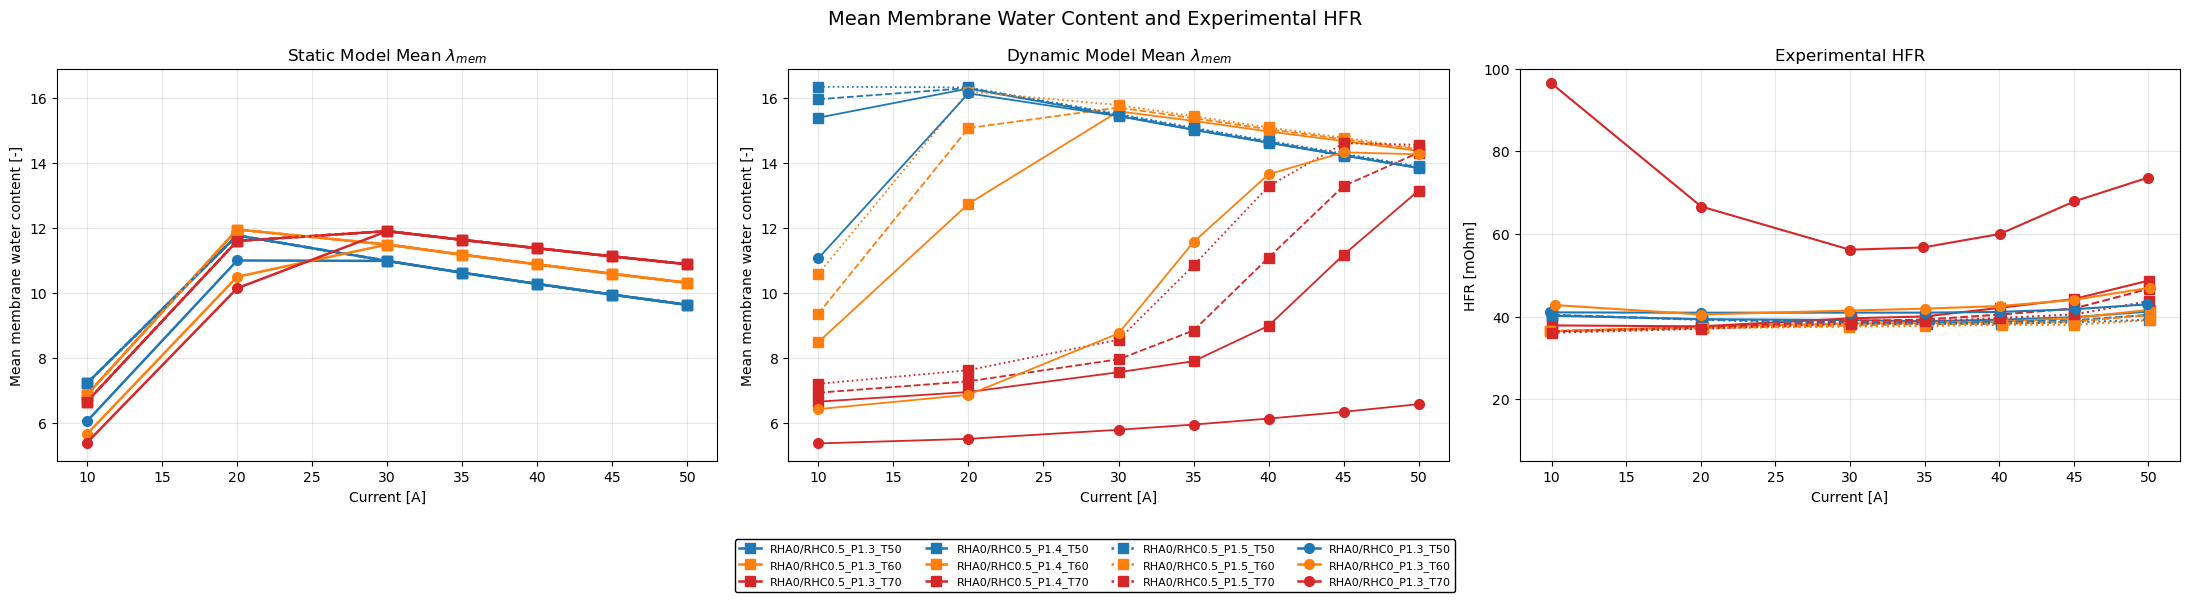

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle("Mean Membrane Water Content and Experimental HFR", fontsize=14)
ax_static, ax_dynamic, ax_exp = axes

handles, labels = [], []
for key in sorted(dyn_log_all.keys()):
    props = get_plot_properties(key)
    states_stat = stat_log_all[key]["states"]
    states_dyn = dyn_log_all[key]["states"]

    lambda_static = np.array([np.mean(states["lambda_mem"]) for states in states_stat], dtype=float)
    lambda_dynamic = np.mean(np.vstack([states_dyn[f"lambda_mem_{i}"] for i in range(1, n_mem + 1)]), axis=0)

    line, = ax_static.plot(I_points, lambda_static, color=props["color"], linestyle=props["linestyle"], marker=props["marker"], linewidth=1.8, markersize=7, label=key)
    ax_dynamic.plot(I_points, lambda_dynamic, color=props["color"], linestyle=props["linestyle"], marker=props["marker"], linewidth=1.3, markersize=7)
    handles.append(line)
    labels.append(key)

    if key in exp_hfr_by_cond:
        x_exp = exp_hfr_by_cond[key]["x"]
        y_exp = exp_hfr_by_cond[key]["y"]
        ax_exp.plot(x_exp, y_exp, color=props["color"], linestyle=props["linestyle"], marker=props["marker"], linewidth=1.5, markersize=7)

ax_static.set_title("Static Model Mean $\\lambda_{mem}$")
ax_static.set_xlabel("Current [A]")
ax_static.set_ylabel("Mean membrane water content [-]")
ax_static.grid(True, alpha=0.3)

ax_dynamic.set_title("Dynamic Model Mean $\\lambda_{mem}$")
ax_dynamic.set_xlabel("Current [A]")
ax_dynamic.set_ylabel("Mean membrane water content [-]")
ax_dynamic.grid(True, alpha=0.3)

ax_exp.set_title("Experimental HFR")
ax_exp.set_xlabel("Current [A]")
ax_exp.set_ylabel("HFR [mOhm]")
ax_exp.grid(True, alpha=0.3)
ax_exp.set_ylim(5, 100)

lam_lo = min(ax_static.get_ylim()[0], ax_dynamic.get_ylim()[0])
lam_hi = max(ax_static.get_ylim()[1], ax_dynamic.get_ylim()[1])
ax_static.set_ylim(lam_lo, lam_hi)
ax_dynamic.set_ylim(lam_lo, lam_hi)

fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0), ncol=4, fontsize=8, frameon=True, facecolor="white", edgecolor="black", framealpha=1.0)
plt.tight_layout(rect=[0, 0.13, 1, 1])
plt.show()

## High-Frequency Resistance (HFR) Calculation and Comparison

This section computes and compares HFR from static simulation, dynamic simulation, and experiment using a unified condition key.

### Theoretical Basis (Thesis-Consistent Formulation)

Following the membrane conductivity correlation used in the thesis/model implementation, each membrane slice resistance is computed from water content $\lambda$ and temperature $T$ using a piecewise conductivity law:

$$R_{mem,i}=\frac{H_{mem}/n_{mem}}{\sigma_{mem}(\lambda_i,T_i)}$$

with

$$\sigma_{mem}(\lambda,T)=\begin{cases}(0.5139\lambda-0.326)\exp\left[1268\left(\frac{1}{303.15}-\frac{1}{T}\right)\right], & \lambda\ge 1\\0.1879\exp\left[1268\left(\frac{1}{303.15}-\frac{1}{T}\right)\right], & \lambda<1\end{cases}$$

The ohmic term is then assembled as:

$$R_{ohm}=\sum_i R_{mem,i}+R_e$$

where $R_e$ is the lumped external resistance.

### Quantities Plotted in This Notebook

- Static HFR uses `Rohm` from the static solver and converts to stack-level mOhm:

$$HFR_{stat}=\frac{R_{ohm}}{A_{act}}\,n_{cell}\times 10^3$$

- Dynamic HFR uses instantaneous transport-state resistances (membrane plus electrode-ionomer terms currently included in code):

$$HFR_{dyn}=\frac{\left(\sum_i R_{mem,i}\right)+R_e+\tfrac{1}{2}R_{ccl}+\tfrac{1}{2}R_{acl}}{A_{act}}\,n_{cell}\times 10^3$$

- Experimental HFR is read from `HFR.xlsx` (column `R`) and converted from tuple-string entries when needed.

### Comparison Objective

The three-panel figure is intended to assess whether the dynamic model better captures operating-condition-dependent resistance trends than the static closure, especially under conditions where hydration and temperature distributions are non-uniform.

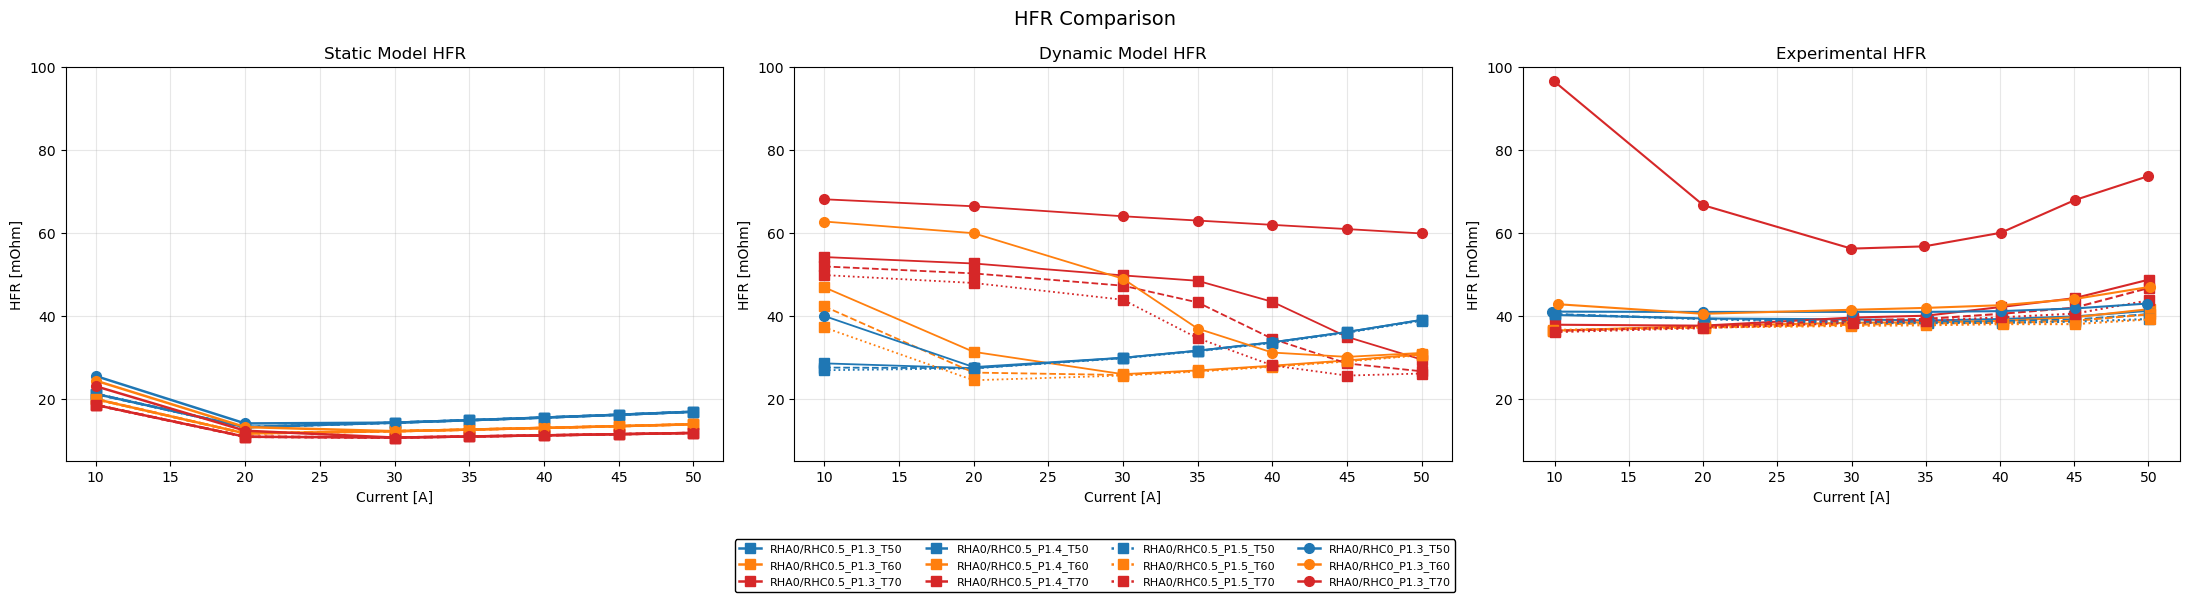

In [ ]:
exp_hfr_by_cond = {}
for sheet in xls.sheet_names:
    df = pd.read_excel(hfr_path, sheet_name=sheet)
    if ("I_LOAD" not in df.columns) or ("R" not in df.columns):
        continue

    m = re.match(r"T(\d+)_P(\d+)_HRC(\d+)", sheet)
    if not m:
        continue

    t_val = int(m.group(1))
    p_tag = int(m.group(2))
    hrc_tag = int(m.group(3))
    p_val = 1.0 + p_tag / 1000.0
    rhc_val = hrc_tag / 100.0
    cond_key = f"RHA0/RHC{rhc_val:g}_P{p_val:.1f}_T{t_val}"

    x_exp = df["I_LOAD"].to_numpy(dtype=float)
    y_exp = np.array([ast.literal_eval(v)[0] if isinstance(v, str) else v for v in df["R"]], dtype=float)
    exp_hfr_by_cond[cond_key] = {"x": x_exp, "y": y_exp}

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle("HFR Comparison", fontsize=14)
ax_static, ax_dynamic, ax_exp = axes

handles, labels = [], []
for key in sorted(dyn_log_all.keys()):
    props = get_plot_properties(key)
    states_stat = stat_log_all[key]["states"]
    states_dyn = dyn_log_all[key]["states"]

    hfr_static = np.array([states["Rohm"] / parameters["Aact"] * n_cell * 1e3 for states in states_stat], dtype=float)
    hfr_dynamic = np.array([(sum(rmem) + parameters["Re"]) / parameters["Aact"] * n_cell * 1e3 for rmem in states_dyn["Rmem"]], dtype=float)
    hfr_dynamic += np.array([(rmem) / parameters["Aact"] * n_cell * 1e3 for rmem in states_dyn["Rccl"]], dtype=float)/2
    hfr_dynamic += np.array([(rmem) / parameters["Aact"] * n_cell * 1e3 for rmem in states_dyn["Racl"]], dtype=float)/2

    line, = ax_static.plot(I_points, hfr_static, color=props["color"], linestyle=props["linestyle"], marker=props["marker"], linewidth=1.8, markersize=7, label=key)
    ax_dynamic.plot(I_points, hfr_dynamic, color=props["color"], linestyle=props["linestyle"], marker=props["marker"], linewidth=1.3, markersize=7)
    handles.append(line)
    labels.append(key)

    if key in exp_hfr_by_cond:
        x_exp = exp_hfr_by_cond[key]["x"]
        y_exp = exp_hfr_by_cond[key]["y"]
        ax_exp.plot(x_exp, y_exp, color=props["color"], linestyle=props["linestyle"], marker=props["marker"], linewidth=1.5, markersize=7)

ax_exp.set_title("Experimental HFR")
ax_exp.set_xlabel("Current [A]")
ax_exp.set_ylabel("HFR [mOhm]")
ax_exp.grid(True, alpha=0.3)
ax_exp.set_ylim(5, 100)  # Ensure y-limits can accommodate experimental data
ax_static.set_title("Static Model HFR")
ax_static.set_xlabel("Current [A]")
ax_static.set_ylabel("HFR [mOhm]")
ax_static.grid(True, alpha=0.3)
ax_static.set_ylim(ax_exp.get_ylim())
ax_dynamic.set_title("Dynamic Model HFR")
ax_dynamic.set_xlabel("Current [A]")
ax_dynamic.set_ylabel("HFR [mOhm]")
ax_dynamic.grid(True, alpha=0.3)
ax_dynamic.set_ylim(ax_exp.get_ylim())

fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0), ncol=4, fontsize=8, frameon=True, facecolor="white", edgecolor="black", framealpha=1.0)

plt.tight_layout(rect=[0, 0.13, 1, 1])
plt.show()